<a href="https://colab.research.google.com/github/thiagopereiramagalhaes/Analise_de_Modelos_de_Regressao-Linear-k-NN-Polinomial_para_Previsao_de_Precos_de_Imoveis_em_Boston/blob/main/An%C3%A1lise_e_Compara%C3%A7%C3%A3o_de_Modelos_de_Regress%C3%A3o_(Linear%2C_k_NN%2C_Polinomial)_para_Previs%C3%A3o_de_Pre%C3%A7os_de_Im%C3%B3veis_em_Boston.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise e Comparação de Modelos de Regressão (Linear, k-NN, Polinomial) para Previsão de Preços de Imóveis em Boston

# Regressão Linear

Base de dados utilizada:
1. Carregamento de dados
2. Análise dos dados
2. Remoção de campo desnecessário (b)
4. Tratamento de dados nulos e/ou faltantes
5. Separação dos dados, holdout
6. Normalização dos dados
7. Treinamento de modelos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## Obtenha os dados
** Leia o arquivo csv 'BostonHousing.csv' em um DataFrame **

**Descrição dos dados**

O conjunto de dados Boston tem 506 linhas e 14 colunas.

Este conjunto de dados contém as seguintes colunas:

* crim: índice de criminalidade per capita por município.

* zn: proporção de terreno residencial zoneada para lotes acima de 25.000 metros quadrados.

* indus: proporção de hectares de negócios não varejistas por cidade.

* chas: Variável fictícia Charles River (= 1 se o trecho limita o rio; 0 caso contrário).

* nox: concentração de óxidos de nitrogênio (partes por 10 milhões).

* rm: número médio de cômodos por domicílio.

* idade / age: proporção de unidades ocupadas pelo proprietário construídas antes de 1940.

* dis: média ponderada das distâncias para cinco centros de emprego de Boston.

* rad: índice de acessibilidade às rodovias radiais.

* imposto / tax: valor total do imposto predial por \$10.000.

* ptratio: relação aluno-professor por município.

* **preto / b**: 1000(Bk - 0,63)^2 onde Bk é a proporção de negros por cidade.

* lstat: status inferior da população (porcentagem).

* medv: valor médio de residências ocupadas pelos proprietários em \$1000s. (**coluna target do nosso modelo**)

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv')

Verifique o cabeçalho do DataFrame

In [ ]:
df.head(5)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


Vamos remover a coluna b porque não vamos utilizar essa informação na nossa modelagem.

In [ ]:
df.drop(columns=['b'], inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  lstat    506 non-null    float64
 12  medv     506 non-null    float64
dtypes: float64(10), int64(3)
memory usage: 51.5 KB


In [ ]:
df.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


## Estatística Descritiva

Dados faltantes

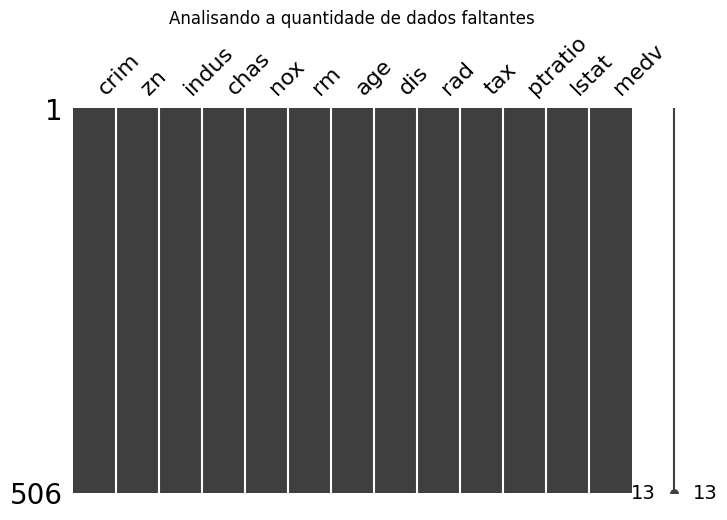

In [ ]:
import missingno as msn

msn.matrix(df, figsize=(8,5))
plt.title("Analisando a quantidade de dados faltantes")
plt.show()

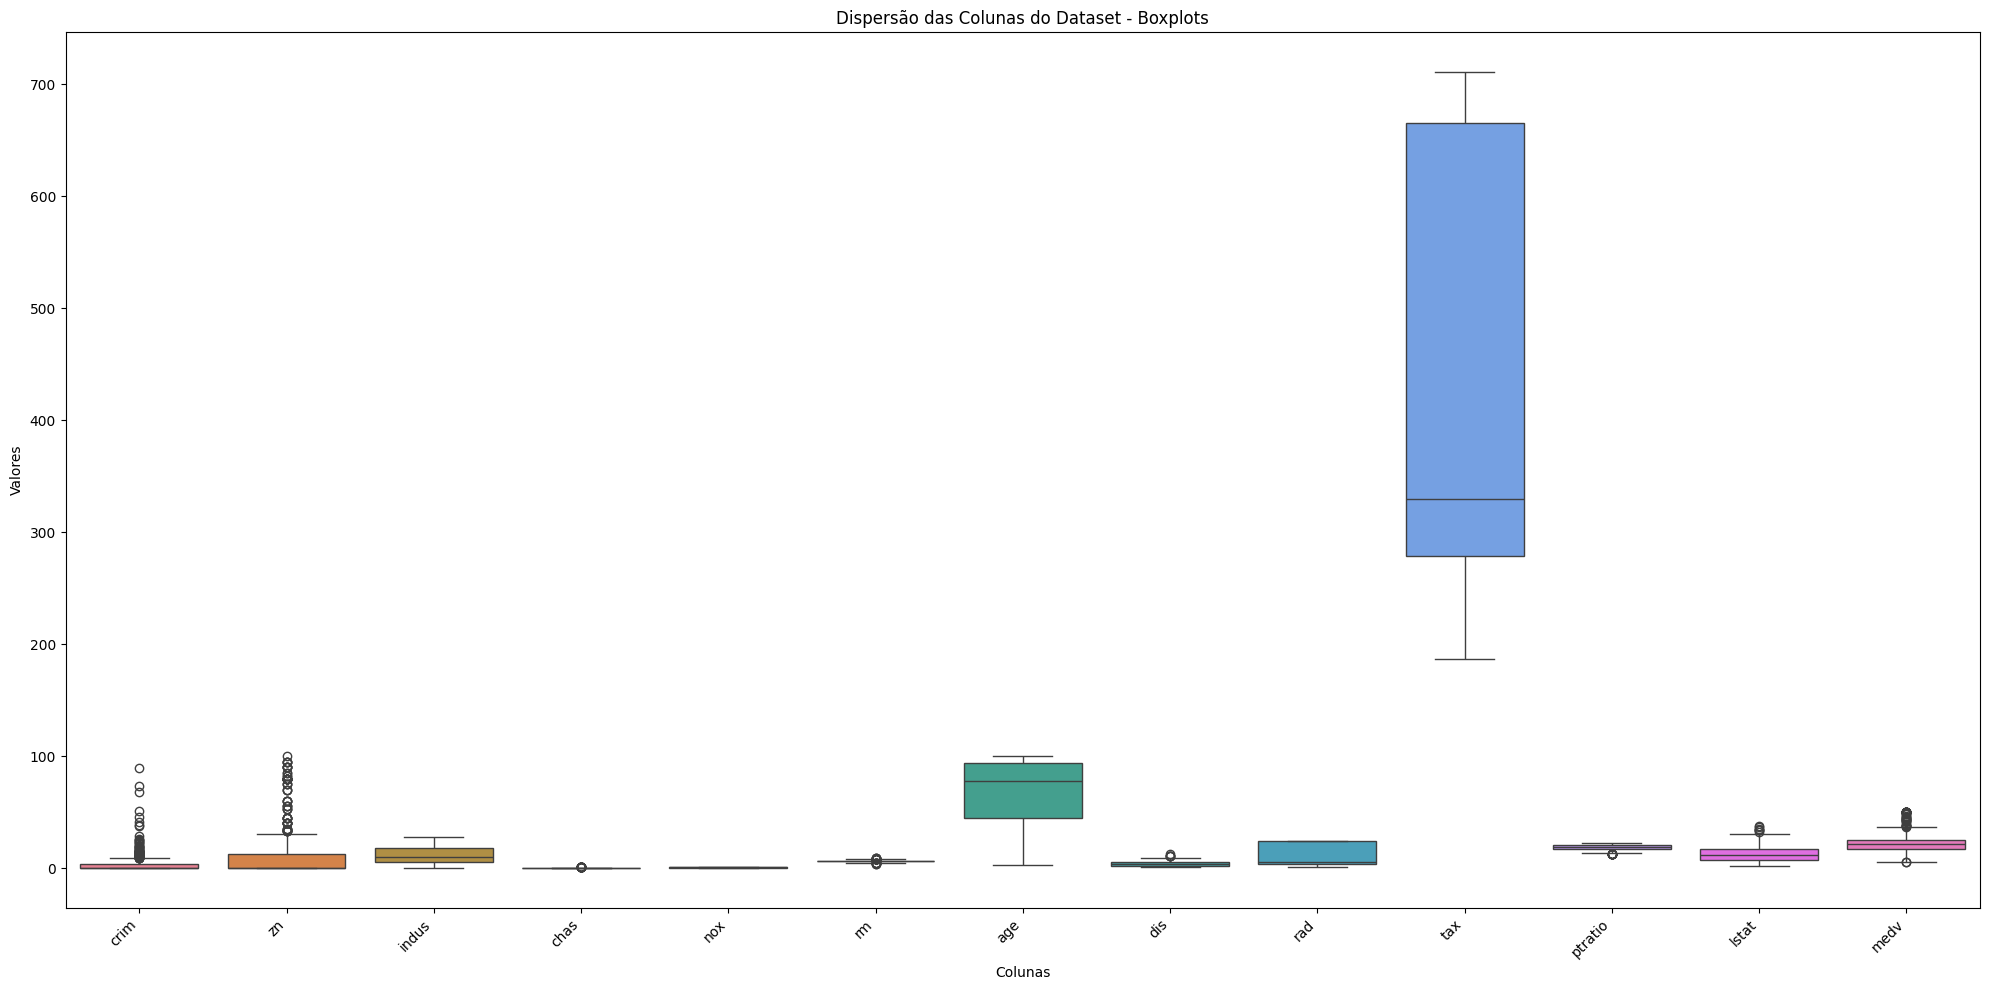

In [ ]:
plt.figure(figsize=(20, 10))
sns.boxplot(data=df)
plt.title('Dispersão das Colunas do Dataset - Boxplots')
plt.xlabel('Colunas')
plt.ylabel('Valores')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Separação dos dados, holdout

Use o método train_test_split para dividir seus dados em um conjunto treino e teste.

A coluna target do nosso modelo é **medv**

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=['medv']),
                                                    df['medv'],
                                                    test_size=0.3,
                                                    random_state=111)

In [ ]:
pd.DataFrame(X_train).head(5)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat
199,0.03150,95.0,1.47,0,0.403,6.975,15.3,7.6534,3,402,17.0,4.56
101,0.11432,0.0,8.56,0,0.520,6.781,71.3,2.8561,5,384,20.9,7.67
386,24.39380,0.0,18.10,0,0.700,4.652,100.0,1.4672,24,666,20.2,28.28
77,0.08707,0.0,12.83,0,0.437,6.140,45.8,4.0905,5,398,18.7,10.27
176,0.07022,0.0,4.05,0,0.510,6.020,47.2,3.5549,5,296,16.6,10.11


## Normalização dos dados

Vamos normalizar os dados.

Import StandardScaler do Scikit-learn.

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()

Converta as variáveis independentes com o StandardScaler

In [ ]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Use o método .transform () para transformar os parâmetros em uma versão padronizada.

In [ ]:
X_test_transformed_example = scaler.transform(X_test)
print(X_test_transformed_example[:5])

[[-0.44944236  0.78943605  0.53926262 -0.28154625 -0.80362068 -0.12149835
  -1.47668018 -0.0423967  -0.65495308 -0.85384111 -0.18236271 -0.95132848]
 [-0.37107324 -0.46194571 -0.74585094 -0.28154625 -0.4262972   0.48980349
   0.4113256  -0.23016722 -0.19764856 -0.63559876 -0.56520272 -0.75021285]
 [-0.44959216  2.88996973 -1.21831916 -0.28154625 -1.11951941  0.45525818
  -1.73496228  0.78497606 -0.76927921 -0.96001306 -0.1345077  -1.22478785]
 [-0.44085045 -0.46194571  2.08168963 -0.28154625  0.22305018 -0.49699088
   0.8514965  -0.79529066 -0.88360534 -1.33751334  0.24833231  0.74440901]
 [-0.44859307  3.78381385 -1.25757036 -0.28154625 -1.22394149  2.34473659
  -1.32025581  0.64998918 -0.65495308 -1.12516943 -1.85728778 -1.29857847]]


In [ ]:
X_train_scaled[:3]

array([[-0.44907456,  3.78381385, -1.43347391, -0.28154625, -1.33889353,
         1.02600682, -1.97141772,  1.85891086, -0.76927921, -0.07524679,
        -0.75662273, -1.19006285],
       [-0.43799762, -0.46194571, -0.40276632, -0.28154625, -0.31222266,
         0.73462462,  0.06573687, -0.42852307, -0.54062695, -0.18141874,
         1.10972235, -0.74008473],
       [ 2.80931263, -0.46194571,  0.98410962, -0.28154625,  1.26727098,
        -2.46306977,  1.10977861, -1.09077412,  1.63156951,  1.48194185,
         0.77473734,  2.24192461]])

Visualizando os dados de treinamento.

In [ ]:
pd.DataFrame(X_train_scaled).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354 entries, 0 to 353
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       354 non-null    float64
 1   1       354 non-null    float64
 2   2       354 non-null    float64
 3   3       354 non-null    float64
 4   4       354 non-null    float64
 5   5       354 non-null    float64
 6   6       354 non-null    float64
 7   7       354 non-null    float64
 8   8       354 non-null    float64
 9   9       354 non-null    float64
 10  10      354 non-null    float64
 11  11      354 non-null    float64
dtypes: float64(12)
memory usage: 33.3 KB


Visualizando os dados de teste.

In [ ]:
pd.DataFrame(X_test_scaled).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 152 entries, 0 to 151
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       152 non-null    float64
 1   1       152 non-null    float64
 2   2       152 non-null    float64
 3   3       152 non-null    float64
 4   4       152 non-null    float64
 5   5       152 non-null    float64
 6   6       152 non-null    float64
 7   7       152 non-null    float64
 8   8       152 non-null    float64
 9   9       152 non-null    float64
 10  10      152 non-null    float64
 11  11      152 non-null    float64
dtypes: float64(12)
memory usage: 14.4 KB


## Regressão Linear

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
reg = LinearRegression()
reg.fit(X_train_scaled, y_train)

LinearRegression()

**Executar o modelo treinado na base de treinamento**

In [ ]:
y_train_pred = reg.predict(X_train_scaled)
y_test_pred = reg.predict(X_test_scaled)

Analisando o score de treino e teste.

In [ ]:
reg.score(X_train_scaled, y_train)

0.7381975510401046

In [ ]:
reg.score(X_test_scaled, y_test)

0.711547915567693

**Avaliação de Regressores - Exibir os Resultados**

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score

In [ ]:
def print_metrics(y_test_in, y_test_pred_in):
  print("MAE: ", mean_absolute_error(y_test_in, y_test_pred_in))
  print("MAPE: ", mean_absolute_percentage_error(y_test_in, y_test_pred_in))
  print("MSE: ", mean_squared_error(y_test_in, y_test_pred_in))
  print("RMSE: ", mean_squared_error(y_test_in, y_test_pred_in)**2)
  print("R²: ", r2_score(y_test_in, y_test_pred_in))

In [ ]:
# dados de treino
print_metrics(y_train, y_train_pred)

MAE:  3.1835585717761252
MAPE:  0.16078737073033178
MSE:  20.374619886830068
RMSE:  415.12513553281127
R²:  0.7381975510401046


In [ ]:
# dados de teste
print_metrics(y_test, y_test_pred)

MAE:  3.701488287606292
MAPE:  0.17831885665559696
MSE:  28.607656840343854
RMSE:  818.3980298948725
R²:  0.711547915567693


## k-NN Regressão

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

In [ ]:
knn = KNeighborsRegressor(n_neighbors=3)
knn.fit(X_train_scaled, y_train)

KNeighborsRegressor(n_neighbors=3)

**Executar o modelo treinado na base de treinamento**

In [ ]:
y_train_knn_pred = knn.predict(X_train_scaled)
y_test_knn_pred = knn.predict(X_test_scaled)

In [ ]:
knn.score(X_train_scaled, y_train)

0.8670591164466853

In [ ]:
knn.score(X_test_scaled, y_test)

0.7597083113180875

**Avaliar o melhor valor de K**

k=1, R2 Score=0.7843
k=2, R2 Score=0.7824
k=3, R2 Score=0.7597
k=4, R2 Score=0.7318
k=5, R2 Score=0.7396
k=6, R2 Score=0.7388
k=7, R2 Score=0.7412
k=8, R2 Score=0.7320
k=9, R2 Score=0.7343
k=10, R2 Score=0.7276
k=11, R2 Score=0.7197
k=12, R2 Score=0.7206
k=13, R2 Score=0.7130
k=14, R2 Score=0.7093
k=15, R2 Score=0.6980
k=16, R2 Score=0.6938
k=17, R2 Score=0.6922
k=18, R2 Score=0.6843
k=19, R2 Score=0.6798
k=20, R2 Score=0.6698
k=21, R2 Score=0.6668
k=22, R2 Score=0.6633
k=23, R2 Score=0.6561
k=24, R2 Score=0.6493
k=25, R2 Score=0.6454
k=26, R2 Score=0.6382
k=27, R2 Score=0.6354
k=28, R2 Score=0.6302
k=29, R2 Score=0.6276


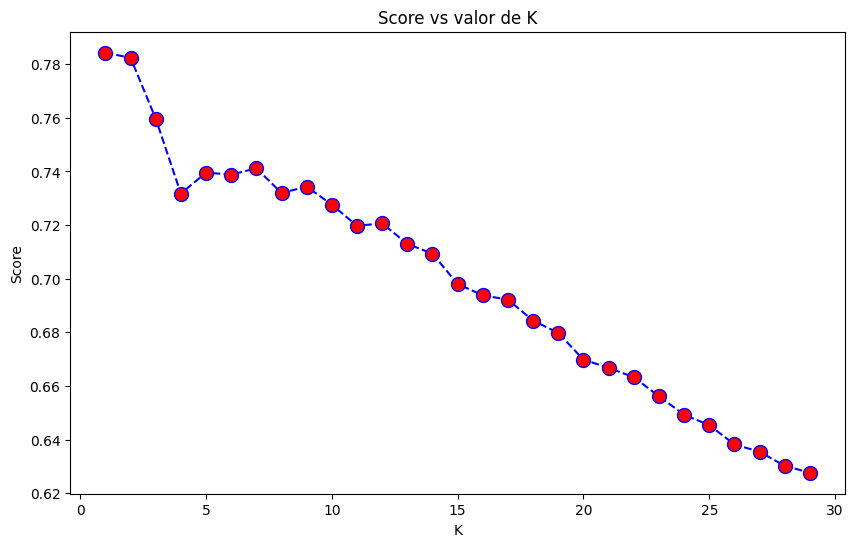

In [ ]:
import numpy as np
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

score = []

for i in range(1,30):
  # treine o modelo
  knn_model = KNeighborsRegressor(n_neighbors=i)
  knn_model.fit(X_train_scaled, y_train)

  # calcule as métricas
  y_pred_knn = knn_model.predict(X_test_scaled)
  r2 = r2_score(y_test, y_pred_knn)

  # armazene na lista score
  score.append(r2)
  print(f"k={i}, R2 Score={r2:.4f}")

plt.figure(figsize=(10,6))
plt.plot(range(1,30), score, color='blue', linestyle='dashed', marker='o',
           markerfacecolor = 'red', markersize=10)
plt.title('Score vs valor de K')
plt.xlabel('K')
plt.ylabel('Score')
plt.show()

### Criar um regressor com o melhor valor para o melhor K e avaliar





In [ ]:
## com o melhor valor de k
print(knn.score(X_train_scaled, y_train))
print(knn.score(X_test_scaled, y_test))

0.8670591164466853
0.7597083113180875


**Avaliação de Regressores - k-NN**

In [ ]:
print('Dados de treino')
print_metrics(y_train, y_train_knn_pred)

Dados de treino
MAE:  1.9395480225988702
MAPE:  0.09057840985071576
MSE:  10.346045197740112
RMSE:  107.04065123368125
R²:  0.8670591164466853


In [ ]:
print("Dados de teste")
print_metrics(y_test, y_test_knn_pred)

Dados de teste
MAE:  3.0506578947368426
MAPE:  0.14024661347440281
MSE:  23.83127923976608
RMSE:  567.9298702037057
R²:  0.7597083113180875


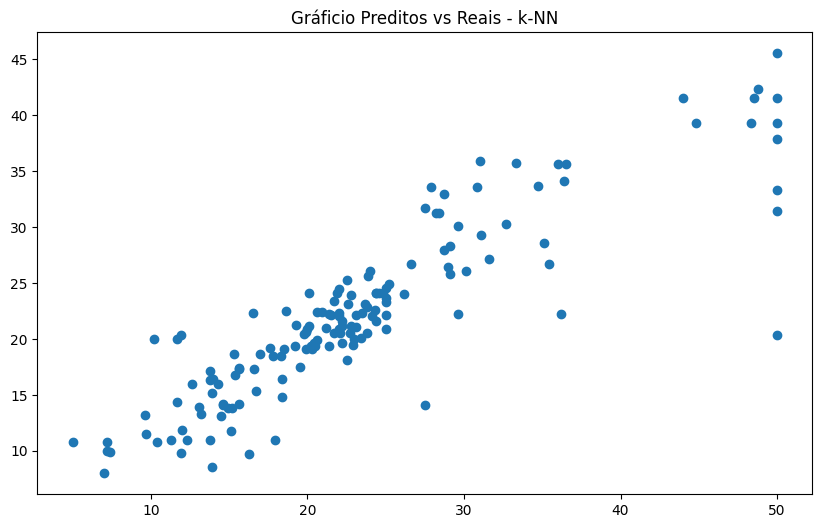

In [ ]:
plt.figure(figsize=(10,6))
plt.title('Gráficio Preditos vs Reais - k-NN')
plt.scatter(y_test, y_test_knn_pred)
plt.show()

## Treinar o modelo de Regressão Polinomial, n=1, n=5, n=10

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

### Com os dados normalizados, aplicar a transformação polinomial de graus 1, 5, 10 e 15

Grau 1

In [ ]:
poly_grau_1 = PolynomialFeatures(degree=1)
X_train_scaled_poly_1 = poly_grau_1.fit_transform(X_train_scaled)
X_test_scaled_poly_1 = poly_grau_1.transform(X_test_scaled)

Grau 5

In [ ]:
poly_grau_5 = PolynomialFeatures(degree=5)
X_train_scaled_poly_5 = poly_grau_5.fit_transform(X_train_scaled)
X_test_scaled_poly_5 = poly_grau_5.transform(X_test_scaled)

Grau 10

In [ ]:
poly_grau_10 = PolynomialFeatures(degree=10)
X_train_scaled_poly_10 = poly_grau_10.fit_transform(X_train_scaled)
X_test_scaled_poly_10 = poly_grau_10.transform(X_test_scaled)

**Treinar o modelo de regressão linear para verificar o melhor resultado da transformação polinomial**

Grau 1

In [ ]:
reg_poly_1 = LinearRegression()
reg_poly_1.fit(X_train_scaled_poly_1, y_train)
y_pred_poly_1 = reg_poly_1.predict(X_test_scaled_poly_1)

In [ ]:
print_metrics(y_test, y_pred_poly_1)

MAE:  3.7014882876062947
MAPE:  0.17831885665559713
MSE:  28.60765684034387
RMSE:  818.3980298948735
R²:  0.7115479155676928


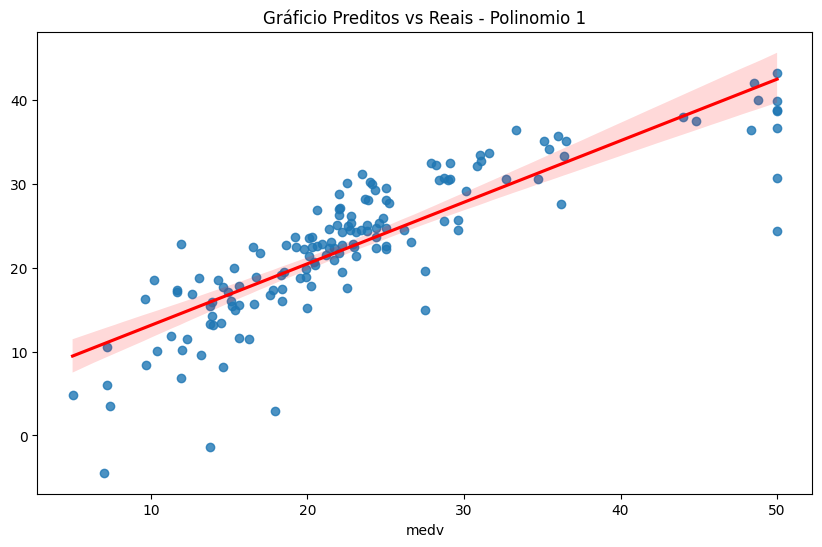

In [ ]:
plt.figure(figsize=(10,6))
plt.title('Gráficio Preditos vs Reais - Polinomio 1')
sns.regplot(x=y_test,y=y_pred_poly_1,line_kws={"color": "red"})
plt.show()

Grau 5

In [ ]:
reg_poly_5 = LinearRegression()
reg_poly_5.fit(X_train_scaled_poly_5, y_train)
y_pred_poly_5 = reg_poly_5.predict(X_test_scaled_poly_5)

In [ ]:
print_metrics(y_test, y_pred_poly_5)

MAE:  111.86301225378274
MAPE:  10.490816949028153
MSE:  1107844.024351937
RMSE:  1227318382292.2952
R²:  -11169.433140806323


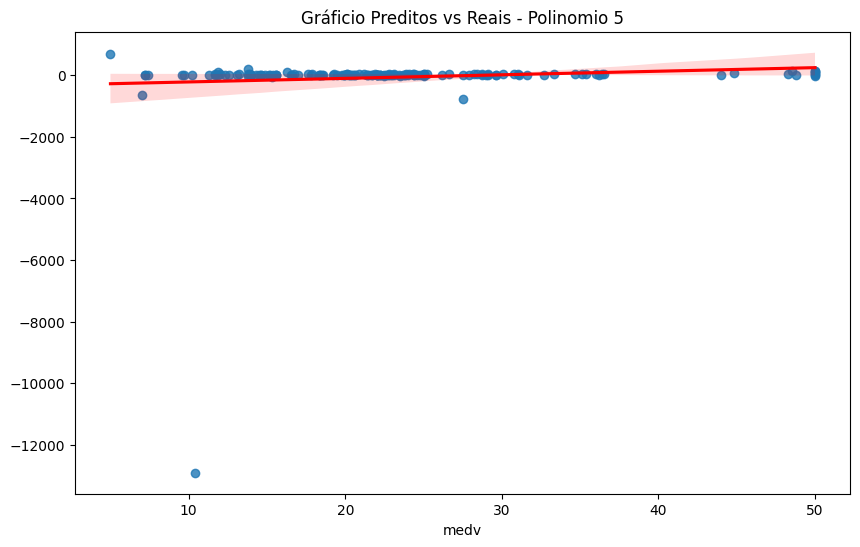

In [ ]:
plt.figure(figsize=(10,6))
plt.title('Gráficio Preditos vs Reais - Polinomio 5')
sns.regplot(x=y_test,y=y_pred_poly_5,line_kws={"color": "red"})
plt.show()

Grau 10

In [ ]:
reg_poly_10 = LinearRegression()
reg_poly_10.fit(X_train_scaled_poly_10, y_train)
y_pred_poly_10 = reg_poly_10.predict(X_test_scaled_poly_10)

In [ ]:
print_metrics(y_test, y_pred_poly_10)

MAE:  61310.04824702118
MAPE:  6040.642738535281
MSE:  534457952687.77765
RMSE:  2.8564530319121077e+23
R²:  -5388959722.42626


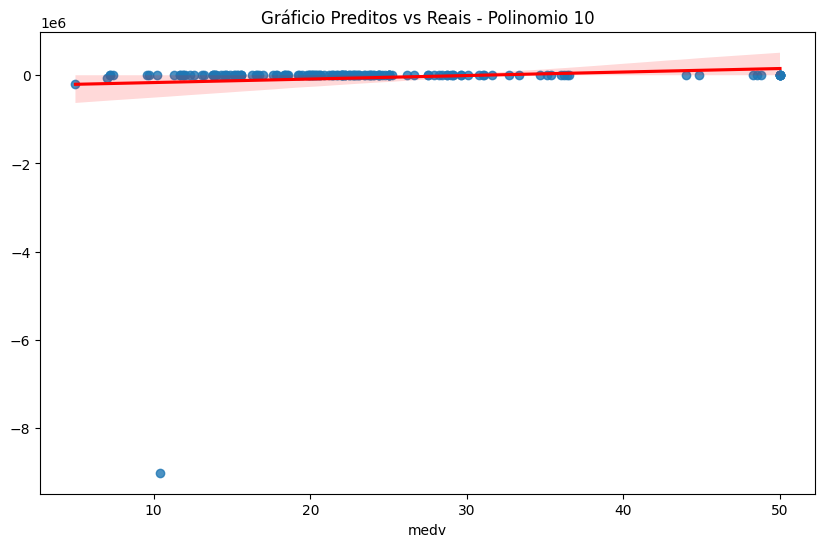

In [ ]:
plt.figure(figsize=(10,6))
plt.title('Gráficio Preditos vs Reais - Polinomio 10')
sns.regplot(x=y_test,y=y_pred_poly_10,line_kws={"color": "red"})
plt.show()

## Conclusão

* A Regressão Linear obteve um R² de aproximadamente 0.71 no conjunto de teste.
* O modelo k-NN, com o valor ideal de K (aparentemente K=1 ou K=2, observando o gráfico 'Score vs valor de K'), demonstrou um desempenho superior, atingindo um R² de 0.7843 para K=1, e 0.7597 para K=3 no conjunto de teste, indicando uma melhor capacidade de generalização.
* Regressão Polinomial de Grau 1 apresentou resultados muito similares à Regressão Linear simples. No entanto, o aumento do grau para 5 e 10 levou a um desempenho pior, com R² negativo e métricas de erro extremamente altas.
* Conclui-se que o modelo k-NN, ajustado com um baixo número de vizinhos (K), foi o mais eficaz para este conjunto de dados.